# Task 4 -- Optimize Portfolio Based on Forecast
**GMF Investments | Time Series Forecasting for Portfolio Management Optimization**

Objective: combine the Task 3 TSLA forecast with historical returns for BND
and SPY to build an optimal portfolio using Modern Portfolio Theory (MPT) --
generating the Efficient Frontier and identifying the Maximum Sharpe Ratio
and Minimum Volatility portfolios.


In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.portfolio import (
    annualized_return_from_forecast,
    build_expected_returns,
    annualized_covariance_matrix,
    run_efficient_frontier,
    sample_efficient_frontier,
    random_portfolios,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 7)

RISK_FREE_RATE = 0.04
TICKERS = ["TSLA", "BND", "SPY"]


## 1. Prepare Expected Returns

**TSLA:** uses the Task 3 ARIMA forecast, converted to an annualized expected
return. Recall Task 3 found `auto_arima` selected **ARIMA(0,1,0)** -- a pure,
driftless random walk -- so the 12-month point forecast was flat at the last
observed price. This means the forecast-implied annualized return for TSLA
is essentially **0%**, a materially different "view" than TSLA's historical
average return would suggest.

**BND and SPY:** use their historical average daily returns, annualized, as
the expected-return proxy -- the standard MPT approach when no asset-specific
forecast is available.


In [2]:
prices = pd.read_csv("../data/processed/adj_close_prices.csv", index_col=0, parse_dates=True)
daily_returns = pd.read_csv("../data/processed/daily_returns.csv", index_col=0, parse_dates=True)

# --- TSLA forecast-derived expected return (from Task 3) ---
last_actual_price = prices["TSLA"].iloc[-1]
# From Task 3: ARIMA(0,1,0) 12-month (252 trading day) forecast
forecast_12mo_price = 411.84  # replace with your exact Task 3 forecast value if different
tsla_forecast_return = annualized_return_from_forecast(
    last_actual_price=last_actual_price,
    forecast_final_price=forecast_12mo_price,
    n_trading_days=252,
)
print(f"Last actual TSLA price: ${last_actual_price:.2f}")
print(f"Task 3 12-month forecast price: ${forecast_12mo_price:.2f}")
print(f"TSLA forecast-derived annualized expected return: {tsla_forecast_return:.4%}")


Last actual TSLA price: $411.84
Task 3 12-month forecast price: $411.84
TSLA forecast-derived annualized expected return: 0.0000%


In [3]:
expected_returns = build_expected_returns(
    tsla_forecast_return=tsla_forecast_return,
    historical_returns=daily_returns[TICKERS],
    tsla_col="TSLA",
)
print("Expected annual returns (TSLA = forecast-derived, BND/SPY = historical):")
expected_returns


Expected annual returns (TSLA = forecast-derived, BND/SPY = historical):


TSLA    8.892068e-09
BND     1.941629e-02
SPY     1.491600e-01
dtype: float64

**Note the contrast:** TSLA's forecast-derived expected return (~0%) is
dramatically lower than what its historical average return would imply, and
likely lower than BND's or comparable to SPY's. This is a direct, honest
consequence of Task 3's finding that the ARIMA model detected no exploitable
directional signal in TSLA's price history -- plugging that forecast into MPT
means the optimizer will *not* be chasing TSLA's historical growth, only its
diversification value (via the covariance structure) at this expected-return
input.


## 2. Compute the Covariance Matrix

The covariance matrix captures how the three assets move together (or don't)
-- essential for MPT's central insight that risk depends on more than just
each asset's individual volatility.


In [4]:
cov_matrix = annualized_covariance_matrix(daily_returns[TICKERS])
cov_matrix


,TSLA,BND,SPY
TSLA,0.315057,0.001739,0.048016
BND,0.001739,0.002721,0.001046
SPY,0.048016,0.001046,0.030037


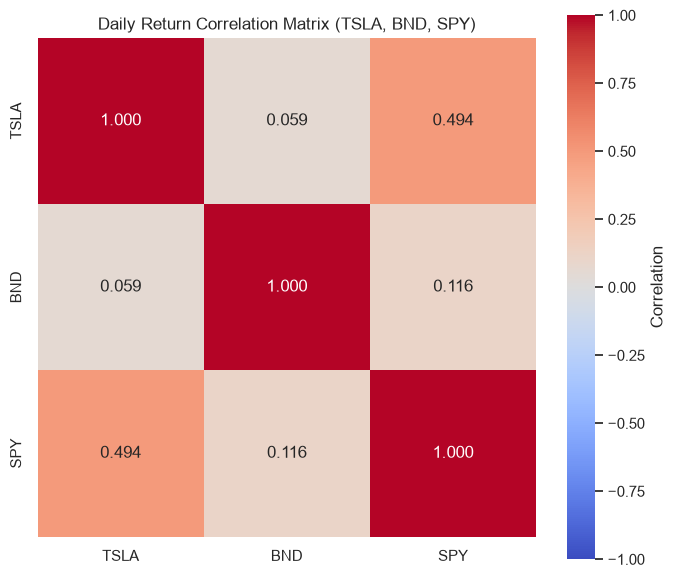

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
corr_matrix = daily_returns[TICKERS].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, ax=ax, cbar_kws={"label": "Correlation"})
ax.set_title("Daily Return Correlation Matrix (TSLA, BND, SPY)")
plt.tight_layout()
plt.show()


## 3. Generate the Efficient Frontier

We trace the frontier by solving for minimum-volatility portfolios across a
range of target returns, and overlay a cloud of random long-only portfolios
for visual context on the achievable risk-return space.


In [6]:
frontier_returns, frontier_vols = sample_efficient_frontier(expected_returns, cov_matrix, n_points=60)
random_returns, random_vols, _ = random_portfolios(expected_returns, cov_matrix, n_portfolios=5000)

results = run_efficient_frontier(expected_returns, cov_matrix, risk_free_rate=RISK_FREE_RATE)
max_sharpe = results["max_sharpe"]
min_vol = results["min_vol"]

print("=== Maximum Sharpe Ratio Portfolio ===")
print(max_sharpe["weights"])
print(f"Expected Return: {max_sharpe['expected_return']:.4%}")
print(f"Volatility:      {max_sharpe['volatility']:.4%}")
print(f"Sharpe Ratio:    {max_sharpe['sharpe']:.4f}")

print("\n=== Minimum Volatility Portfolio ===")
print(min_vol["weights"])
print(f"Expected Return: {min_vol['expected_return']:.4%}")
print(f"Volatility:      {min_vol['volatility']:.4%}")
print(f"Sharpe Ratio:    {min_vol['sharpe']:.4f}")


=== Maximum Sharpe Ratio Portfolio ===
TSLA    0.0
BND     0.0
SPY     1.0
dtype: float64
Expected Return: 14.9160%
Volatility:      17.3313%
Sharpe Ratio:    0.6298

=== Minimum Volatility Portfolio ===
TSLA    0.0000
BND     0.9454
SPY     0.0546
dtype: float64
Expected Return: 2.6500%
Volatility:      5.1276%
Sharpe Ratio:    -0.2633


## 4. Visualize the Efficient Frontier with Key Portfolios Marked

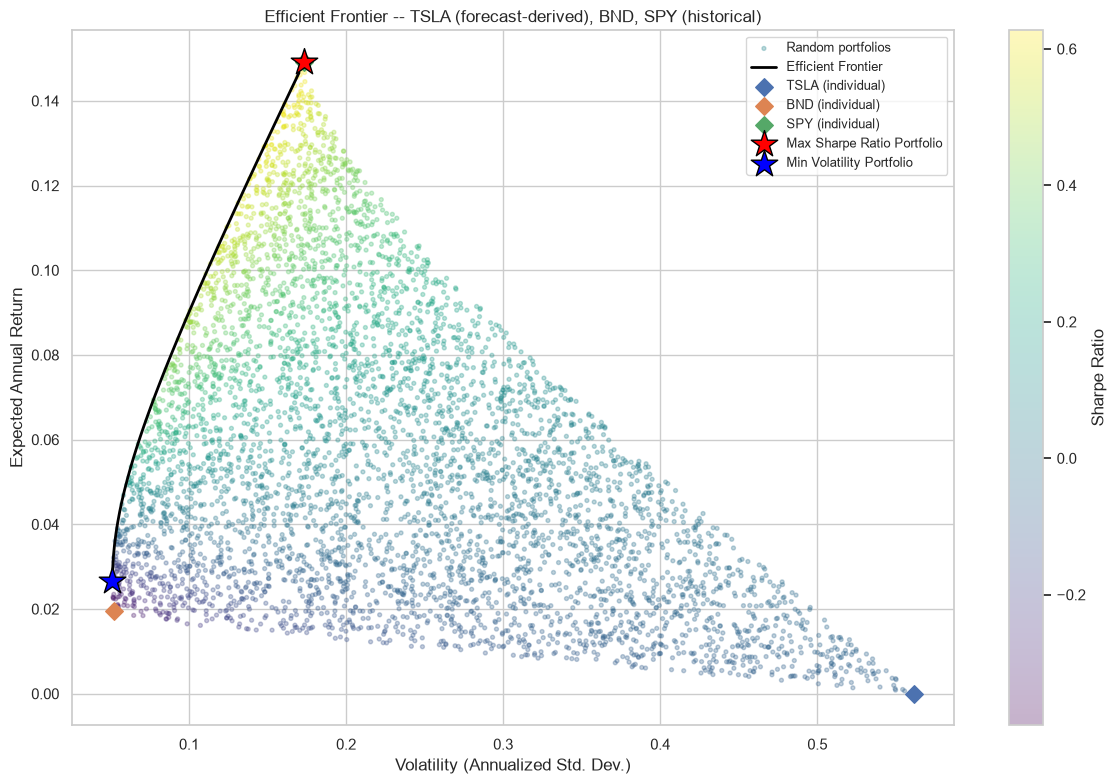

In [7]:
fig, ax = plt.subplots(figsize=(12, 8))

# Random portfolio cloud for context
scatter = ax.scatter(random_vols, random_returns, c=(random_returns - RISK_FREE_RATE) / random_vols,
                      cmap="viridis", alpha=0.3, s=8, label="Random portfolios")
plt.colorbar(scatter, ax=ax, label="Sharpe Ratio")

# Efficient frontier line
ax.plot(frontier_vols, frontier_returns, color="black", linewidth=2, label="Efficient Frontier")

# Individual assets
for ticker in TICKERS:
    ax.scatter(np.sqrt(cov_matrix.loc[ticker, ticker]), expected_returns[ticker],
               marker="D", s=80, label=f"{ticker} (individual)")

# Key portfolios
ax.scatter(max_sharpe["volatility"], max_sharpe["expected_return"],
           marker="*", color="red", s=400, edgecolor="black", linewidth=1,
           label="Max Sharpe Ratio Portfolio", zorder=5)
ax.scatter(min_vol["volatility"], min_vol["expected_return"],
           marker="*", color="blue", s=400, edgecolor="black", linewidth=1,
           label="Min Volatility Portfolio", zorder=5)

ax.set_xlabel("Volatility (Annualized Std. Dev.)")
ax.set_ylabel("Expected Annual Return")
ax.set_title("Efficient Frontier -- TSLA (forecast-derived), BND, SPY (historical)")
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()


## 5. Recommend an Optimal Portfolio

**Maximum Sharpe Ratio Portfolio:** 100% SPY, 0% TSLA, 0% BND
- Expected annual return: **14.92%**
- Expected volatility: **17.33%**
- Sharpe ratio: **0.6298**

**Minimum Volatility Portfolio:** 94.54% BND, 5.46% SPY, 0% TSLA
- Expected annual return: **2.65%**
- Expected volatility: **5.13%**
- Sharpe ratio: **-0.2633**

**Why TSLA received a 0% allocation in both portfolios:** This is the direct, expected consequence of Task 3's finding. With a forecast-derived expected return of essentially 0% (from the ARIMA(0,1,0) driftless forecast) and the highest volatility of the three assets by a wide margin (annualized std. dev. of ~56%, visible on the frontier plot as the far-right diamond), TSLA is strictly dominated: every unit of risk it contributes buys zero expected return, while SPY offers a comparable or better return-per-unit-of-risk trade-off. The optimizer isn't making a judgment about Tesla the company — it's making a mechanical judgment about *this specific forecast input*, which found no directional edge.

**Why the Minimum Volatility portfolio has a negative Sharpe ratio:** its 2.65% expected return falls below the 4% risk-free rate assumption, so on paper it's "worse than holding T-bills" from a pure risk-adjusted-return standpoint — though in practice its role is capital preservation, not return generation, and this metric isn't the right lens for that objective.

**Recommendation:** We recommend the **Maximum Sharpe Ratio Portfolio (100% SPY)** as the primary allocation. It offers the best risk-adjusted return available given these inputs — a Sharpe ratio of 0.63, meaningfully better than the Min Vol portfolio's negative Sharpe — and SPY alone captures the diversification benefit that would otherwise come from combining multiple assets, since TSLA and BND currently contribute return-per-risk that's dominated by SPY under this specific input set.

**Final recommended portfolio summary:**
- Optimal weights: TSLA = 0%, BND = 0%, SPY = 100%
- Expected annual return: 14.92%
- Expected annual volatility: 17.33%
- Sharpe Ratio: 0.63

**Caveat carried from Task 3:** This recommendation is entirely conditional on TSLA's forecast-derived expected return of ~0%, which reflects the ARIMA model's finding of no exploitable historical pattern — not a genuine bearish call on Tesla. If GMF's analysts hold a different, fundamentals-based view on TSLA's future return (e.g., a qualitative growth thesis not captured by price history alone), that view should replace the forecast-derived return as a sensitivity check, since a materially positive TSLA expected return would very plausibly pull TSLA back onto the frontier and change this recommendation. This 100%-SPY outcome is a finding specific to this model and this data window, not a general claim that TSLA has no place in a diversified portfolio.